# DETECTive — Machine Learning ATPG for Digital Circuits

Implementation of the paper *"DETECTive: Machine Learning-driven Automatic Test
Pattern Prediction for Faults in Digital Circuits"* (GLSVLSI 2024).

**Kaggle version** — runs on Kaggle CPU/GPU notebooks.

## Before running
1. Go to **Settings → Accelerator** and select **GPU T4 x2** (or CPU if unavailable)
2. Run all cells top to bottom with **Run All**
3. Outputs are saved to `/kaggle/working/` and persist for the session
4. To resume training after a session timeout, re-run all cells — the checkpoint is auto-loaded

| Phase | What it does |
|---|---|
| 1 | Verilog parser → PyG graph |
| 2 | GNN: GAT + GCN embeddings |
| 3 | PathExtractor + LSTM encoders |
| 4 | InputPredictor (cone embedding) |
| 5 | Master model + smoke test |
| 6 | Dataset generation (2-5 min) |
| 7 | Training loop — 1000 epochs, checkpointed |
| 8 | Inference on any Verilog circuit |


## Setup


In [1]:
import os, sys

# ── Kaggle: output directory persists for the session ────────────
SAVE_PATH = "/kaggle/working/"
os.makedirs(SAVE_PATH, exist_ok=True)

# ── GPU compatibility check ───────────────────────────────────────
# Kaggle may assign a Tesla P100 (sm_60) which is incompatible with
# PyTorch >= 2.0 (requires sm_70+). Detect and fall back to CPU.
import torch

def _check_gpu():
    if not torch.cuda.is_available():
        return False
    try:
        cap = torch.cuda.get_device_capability(0)
        if cap[0] < 7:
            print(f"[WARN] GPU sm_{cap[0]}{cap[1]} is incompatible with PyTorch >= 2.0.")
            print("       Falling back to CPU. Training will be slower.")
            return False
        return True
    except Exception:
        return False

_GPU_OK = _check_gpu()
if _GPU_OK:
    torch.backends.cudnn.benchmark = True
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
    except AttributeError:
        pass
    print(f"GPU  : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("Device: CPU")

EPOCHS    = 1000
LOG_EVERY = 10
RESUME    = True   # set False to retrain from scratch

print(f"PyTorch   : {torch.__version__}")
print(f"Save path : {SAVE_PATH}")


GPU  : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM : 6.4 GB
PyTorch   : 2.7.1+cu118
Save path : /kaggle/working/


## Dependencies

`torch_geometric` is the only extra install needed.


In [2]:
import subprocess
# Kaggle has torch pre-installed; only PyG needs installing
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch_geometric"])

from torch_geometric.data import Data
from torch_geometric.nn import GATConv, GCNConv

# Verify it works on the chosen device
_dev = torch.device("cuda" if _GPU_OK else "cpu")
_x   = torch.ones(3, 4).to(_dev)
_ei  = torch.tensor([[0,1],[1,2]], dtype=torch.long).to(_dev)
_d   = Data(x=_x, edge_index=_ei)
print(f"torch_geometric OK — test graph on {_d.x.device}")


c:\Users\prash\OneDrive\Desktop\project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch_geometric OK — test graph on cuda:0


## Phase 1 — Circuit graph builder

Parses a Verilog netlist and builds a PyG `Data` object. Each node carries:
- **gate-type one-hot** (9 dims): INPUT AND NAND OR NOR XOR XNOR NOT BUF
- **fault flag** (1 dim): 1.0 if this node is the injected fault site
- **log1p(fanout)** (1 dim): normalised fanout count


In [3]:
import re, math
import torch
from torch_geometric.data import Data

GATE_TYPES  = ["INPUT","AND","NAND","OR","NOR","XOR","XNOR","NOT","BUF"]
GATE_TO_IDX = {g: i for i, g in enumerate(GATE_TYPES)}


class CircuitGraphBuilder:
    """
    Parses a Verilog netlist and converts it into a PyTorch Geometric Data object.
    Fanout is log1p-normalised to match scale of one-hot and fault-flag channels.
    """
    def __init__(self, netlist):
        self.raw_netlist      = netlist
        self.netlist          = self._clean_verilog(netlist)
        self.gates            = {}
        self.explicit_outputs = []
        self._parse_verilog()
        self._calculate_fanouts()

    def _clean_verilog(self, text):
        text = re.sub(r"/\*[\s\S]*?\*/", "", text)
        text = re.sub(r"//.*", "", text)
        text = text.replace("\n", " ")
        return text

    def _parse_verilog(self):
        for group in re.findall(r"input\s+([^;]+);", self.netlist):
            for inp in group.split(","):
                name = inp.strip()
                if name:
                    self.gates[name] = {"type":"INPUT","inputs":[],"fanout":0}
        for group in re.findall(r"output\s+([^;]+);", self.netlist):
            for out in group.split(","):
                name = out.strip()
                if name:
                    self.explicit_outputs.append(name)
        pattern = r"(and|or|nand|nor|xor|xnor|not|buf)\s+\w+\s*\(([^)]+)\);"
        for gtype, args in re.findall(pattern, self.netlist, re.IGNORECASE):
            tokens   = [t.strip() for t in args.split(",")]
            out_node = tokens[0]
            in_nodes = tokens[1:]
            self.gates[out_node] = {"type":gtype.upper(),"inputs":in_nodes,"fanout":0}

    def _calculate_fanouts(self):
        for node, data in self.gates.items():
            for inp in data["inputs"]:
                if inp in self.gates:
                    self.gates[inp]["fanout"] += 1

    def get_pyg_graph(self, faulty_node=None):
        node_names = list(self.gates.keys())
        name_to_id = {name: i for i, name in enumerate(node_names)}
        num_nodes  = len(node_names)
        feature_dim = len(GATE_TYPES) + 2
        x = torch.zeros((num_nodes, feature_dim), dtype=torch.float)
        for i, name in enumerate(node_names):
            gdata = self.gates[name]
            x[i, GATE_TO_IDX.get(gdata["type"], 0)] = 1.0
            x[i, len(GATE_TYPES)]     = 1.0 if name == faulty_node else 0.0
            x[i, len(GATE_TYPES) + 1] = math.log1p(float(gdata["fanout"]))
        src, dst = [], []
        for target_name, data in self.gates.items():
            target_id = name_to_id[target_name]
            for src_name in set(data["inputs"]):
                if src_name in name_to_id:
                    src.append(name_to_id[src_name])
                    dst.append(target_id)
        edge_index = torch.tensor([src, dst], dtype=torch.long)
        return Data(x=x, edge_index=edge_index), name_to_id


# ── Phase 1 test ─────────────────────────────────────────────────
_net_p1 = """
    module simple_and_or_circuit (a,b,c,e);
        input a,b,c; output e; wire d;
        and G1(d, a, b);
        or  G2(e, d, c);
    endmodule
"""
builder_p1    = CircuitGraphBuilder(_net_p1)
graph_p1, node_map_p1 = builder_p1.get_pyg_graph(faulty_node="d")
print("--- Phase 1 Verification ---")
print(f"Nodes: {graph_p1.num_nodes}, Edges: {graph_p1.num_edges}")
print(f"Feature shape: {graph_p1.x.shape}  (expected [5, 11])")
d_feat = graph_p1.x[node_map_p1["d"]]
print(f"Fault flag at d (idx 9): {d_feat[9].item()}  (expected 1.0)")
print(f"Fanout at d (idx 10): {d_feat[10].item():.4f}  (expected {math.log1p(1):.4f})")
print("[PASS] Phase 1")


--- Phase 1 Verification ---
Nodes: 5, Edges: 4
Feature shape: torch.Size([5, 11])  (expected [5, 11])
Fault flag at d (idx 9): 1.0  (expected 1.0)
Fanout at d (idx 10): 0.6931  (expected 0.6931)
[PASS] Phase 1


## Phase 2 — Graph representation learning

Paper architecture: 1× GAT → 2× GCN, hidden dim 32.


In [4]:
import torch.nn as nn
import torch.nn.functional as F


class DETECTiveGNN(nn.Module):
    """1 GAT layer + 2 GCN layers -> 32-dim topology-aware embeddings."""
    def __init__(self, in_channels=11, hidden_channels=32):
        super().__init__()
        self.gat  = GATConv(in_channels,     hidden_channels)
        self.gcn1 = GCNConv(hidden_channels, hidden_channels)
        self.gcn2 = GCNConv(hidden_channels, hidden_channels)

    # ← forward is NOW INSIDE the class (fixed indentation)
    def forward(self, x, edge_index):
        x = F.relu(self.gat(x,  edge_index))
        x = F.relu(self.gcn1(x, edge_index))
        x = self.gcn2(x, edge_index)
        return x


_gnn = DETECTiveGNN(in_channels=11, hidden_channels=32)
_gnn.eval()
with torch.no_grad():
    node_embeddings = _gnn(graph_p1.x, graph_p1.edge_index)
print("--- Phase 2 Verification ---")
print(f"Output shape: {node_embeddings.shape}  (expected [{graph_p1.num_nodes}, 32])")
assert not torch.isnan(node_embeddings).any()
print("[PASS] Phase 2")


--- Phase 2 Verification ---
Output shape: torch.Size([5, 32])  (expected [5, 32])
[PASS] Phase 2


## Phase 3 — Path extraction + LSTM path encoders

`PathExtractor` uses BFS (first path) + capped DFS (up to p=10 paths).
Hard node-visit limit of 500 prevents exponential blow-up on reconvergent circuits.


In [5]:
from collections import deque


class PathExtractor:
    """
    BFS for shortest path + capped DFS for additional paths.
    Hard limit _MAX_NODES=500 per DFS call prevents crash on
    dense tech-mapped circuits (XOR reconvergent stems).
    """
    _MAX_NODES = 500

    def __init__(self, edge_index, num_nodes, explicit_pos=None):
        self.num_nodes = num_nodes
        self.adj  = {i: [] for i in range(num_nodes)}
        self.radj = {i: [] for i in range(num_nodes)}
        in_deg  = {i: 0 for i in range(num_nodes)}
        out_deg = {i: 0 for i in range(num_nodes)}
        ei_cpu  = edge_index.cpu() if edge_index.device.type != "cpu" else edge_index
        for u, v in zip(ei_cpu[0].tolist(), ei_cpu[1].tolist()):
            self.adj[u].append(v); self.radj[v].append(u)
            out_deg[u] += 1; in_deg[v] += 1
        self.pis = [i for i in range(num_nodes) if in_deg[i] == 0]
        self.pos = (set(explicit_pos) if explicit_pos
                    else {i for i in range(num_nodes) if out_deg[i] == 0})

    def _bfs_one_path(self, start, target_or_pos, to_po=False):
        if to_po and start in self.pos: return [start]
        if not to_po and start == target_or_pos: return [start]
        parent = {start: None}; q = deque([start])
        while q:
            cur = q.popleft()
            for nb in self.adj.get(cur, []):
                if nb not in parent:
                    parent[nb] = cur
                    if (to_po and nb in self.pos) or (not to_po and nb == target_or_pos):
                        path = []; n = nb
                        while n is not None: path.append(n); n = parent[n]
                        return path[::-1]
                    q.append(nb)
        return []

    def _dfs_capped(self, start, target_or_pos, max_paths, to_po=False):
        paths = []; nodes_seen = 0
        stack = [(start, [start], {start})]
        while stack and len(paths) < max_paths and nodes_seen < self._MAX_NODES:
            cur, path, visited = stack.pop()
            nodes_seen += 1
            if (to_po and cur in self.pos) or (not to_po and cur == target_or_pos):
                paths.append(list(path)); continue
            for nb in self.adj.get(cur, []):
                if nb not in visited:
                    stack.append((nb, path + [nb], visited | {nb}))
        return paths

    def get_activation_paths(self, fault_idx, max_paths=10):
        if fault_idx is None or fault_idx not in self.adj: return []
        res = []
        for pi in self.pis:
            if len(res) >= max_paths: break
            p1 = self._bfs_one_path(pi, fault_idx)
            if not p1: continue
            res.append(p1)
            if len(res) >= max_paths: break
            extra = self._dfs_capped(pi, fault_idx, max_paths - len(res))
            seen  = {tuple(p) for p in res}
            for p in extra:
                if tuple(p) not in seen: res.append(p); seen.add(tuple(p))
                if len(res) >= max_paths: break
        return res

    def get_propagation_paths(self, fault_idx, max_paths=10):
        if fault_idx is None or fault_idx not in self.adj: return []
        p1  = self._bfs_one_path(fault_idx, self.pos, to_po=True)
        res = [p1] if p1 else []
        if len(res) >= max_paths: return res
        extra = self._dfs_capped(fault_idx, self.pos, max_paths - len(res), to_po=True)
        seen  = {tuple(p) for p in res}
        for p in extra:
            if tuple(p) not in seen: res.append(p); seen.add(tuple(p))
            if len(res) >= max_paths: break
        return res

    def reachable_from_pis(self):
        vis = set(self.pis); q = deque(self.pis)
        while q:
            n = q.popleft()
            for nb in self.adj.get(n, []):
                if nb not in vis: vis.add(nb); q.append(nb)
        return vis

    def reachable_to_pos(self):
        vis = set(self.pos); q = deque(self.pos)
        while q:
            n = q.popleft()
            for nb in self.radj.get(n, []):
                if nb not in vis: vis.add(nb); q.append(nb)
        return vis


class Activator(nn.Module):
    """LSTM encoder + MLP consuming fault type."""
    def __init__(self, in_channels=32, hidden_channels=32):
        super().__init__()
        self.lstm = nn.LSTM(in_channels, hidden_channels, batch_first=True)
        self.mlp  = nn.Sequential(nn.Linear(hidden_channels + 1, 16),
                                   nn.ReLU(), nn.Linear(16, 1))
    def forward(self, path_seq, fault_type):
        _, (h, _) = self.lstm(path_seq)
        enc = h[-1]
        return enc, torch.sigmoid(self.mlp(torch.cat([enc, fault_type], dim=1)))


class Propagator(nn.Module):
    """LSTM encoder + MLP (no fault type)."""
    def __init__(self, in_channels=32, hidden_channels=32):
        super().__init__()
        self.lstm = nn.LSTM(in_channels, hidden_channels, batch_first=True)
        self.mlp  = nn.Sequential(nn.Linear(hidden_channels, 16),
                                   nn.ReLU(), nn.Linear(16, 1))
    def forward(self, path_seq):
        _, (h, _) = self.lstm(path_seq)
        enc = h[-1]
        return enc, torch.sigmoid(self.mlp(enc))


# ── Phase 3 test ─────────────────────────────────────────────────
_ep  = [node_map_p1[o] for o in builder_p1.explicit_outputs if o in node_map_p1]
_ext = PathExtractor(graph_p1.edge_index, graph_p1.num_nodes, explicit_pos=_ep)
_fi  = node_map_p1.get("d", 0)
_ap  = _ext.get_activation_paths(_fi)
_pp  = _ext.get_propagation_paths(_fi)
print("--- Phase 3 Verification ---")
print(f"Activation paths: {len(_ap)}, Propagation paths: {len(_pp)}")
_act_mod = Activator(); _prop_mod = Propagator()
if _ap:
    _seq = node_embeddings[_ap[0]].unsqueeze(0)
    _enc, _pred = _act_mod(_seq, torch.tensor([[0.0]]))
    print(f"Activator  enc: {_enc.shape}  pred: {_pred.item():.4f}")
if _pp:
    _seq = node_embeddings[_pp[0]].unsqueeze(0)
    _enc, _pred = _prop_mod(_seq)
    print(f"Propagator enc: {_enc.shape}  pred: {_pred.item():.4f}")
print("[PASS] Phase 3")


--- Phase 3 Verification ---
Activation paths: 2, Propagation paths: 1
Activator  enc: torch.Size([1, 32])  pred: 0.4801
Propagator enc: torch.Size([1, 32])  pred: 0.4510
[PASS] Phase 3


## Phase 4 — InputPredictor (cone of influence)


In [6]:
class InputPredictor(nn.Module):
    def __init__(self, p=10, path_encoding_dim=32):
        super().__init__()
        self.p   = p
        self.dim = path_encoding_dim
        cone_dim = p * (path_encoding_dim + 1) * 2
        self.mlp = nn.Sequential(nn.Linear(cone_dim, 64), nn.ReLU(),
                                  nn.Linear(64, 1))

    def _pack(self, encs, preds, device):
        encs  = encs[:self.p]; preds = preds[:self.p]
        n     = len(encs)
        parts = []
        for enc, pred in zip(encs, preds):
            parts.append(enc.to(device).view(1, -1))
            parts.append(pred.to(device).view(1, -1))
        for _ in range(self.p - n):
            parts.append(torch.zeros(1, self.dim, device=device))
            parts.append(torch.zeros(1, 1,        device=device))
        return torch.cat(parts, dim=1)

    def forward(self, act_enc, act_pred, prop_enc, prop_pred):
        # ── Always use the device the MLP lives on ──────────────
        # Old code used torch.cuda.is_available() as a fallback,
        # which put `cone` on GPU while self.mlp was still on CPU
        # whenever the lists were empty. This fixes that.
        dev = next(self.mlp.parameters()).device

        cone = torch.cat([self._pack(act_enc,  act_pred,  dev),
                           self._pack(prop_enc, prop_pred, dev)], dim=1)
        return torch.sigmoid(self.mlp(cone)), cone
# ── Phase 4 test ─────────────────────────────────────────────────
print("--- Phase 4 Verification ---")
_pred4 = InputPredictor(p=10)
for label, na, np_ in [("0 paths",0,0),("10 paths",10,10),("15 paths",15,15)]:
    _ea = [torch.zeros(1,32) for _ in range(na)]
    _pa = [torch.zeros(1,1)  for _ in range(na)]
    _ep2= [torch.zeros(1,32) for _ in range(np_)]
    _pp2= [torch.zeros(1,1)  for _ in range(np_)]
    _out, _cone = _pred4(_ea, _pa, _ep2, _pp2)
    assert _out.shape == (1,1)
    assert _cone.shape == (1, 10*(32+1)*2)
    print(f"  {label:>9}: cone={tuple(_cone.shape)}  out={_out.item():.4f}  OK")
print("[PASS] Phase 4")


--- Phase 4 Verification ---
    0 paths: cone=(1, 660)  out=0.4859  OK
   10 paths: cone=(1, 660)  out=0.4859  OK
   15 paths: cone=(1, 660)  out=0.4859  OK
[PASS] Phase 4


## Phase 5 — Master model + smoke test


In [7]:
import torch.optim as optim


class DETECTiveModel(nn.Module):
    def __init__(self, in_channels=11, hidden_channels=32, p=10):
        super().__init__()
        self.gnn        = DETECTiveGNN(in_channels, hidden_channels)
        self.activator  = Activator(hidden_channels, hidden_channels)
        self.propagator = Propagator(hidden_channels, hidden_channels)
        self.predictor  = InputPredictor(p=p, path_encoding_dim=hidden_channels)

    def encode(self, graph):
        """
        Stage 1: run the GNN ONCE and return node embeddings.
        Call this once per sample, then pass the result to forward_single/forward.
        """
        return self.gnn(graph.x, graph.edge_index)

    def forward_single(self, node_emb, pi, fault_type, act_paths, prop_paths):
        """
        Stage 2: encode paths and predict for ONE PI.
        Receives pre-computed node_emb — GNN is NOT called here.

        Args:
            node_emb   : [num_nodes, hidden] tensor from self.encode()
            pi         : int, index of the target primary input
            fault_type : [1,1] tensor
            act_paths  : list of activation paths (pre-computed)
            prop_paths : list of propagation paths (pre-computed)
        """
        # Filter activation paths to those starting from this PI
        tgt_act = [p for p in (act_paths or []) if p and p[0] == pi]

        act_enc, act_pred = [], []
        for path in tgt_act:
            seq = node_emb[path].unsqueeze(0)          # [1, L, hidden]
            e, y = self.activator(seq, fault_type)
            act_enc.append(e); act_pred.append(y)

        prop_enc, prop_pred = [], []
        for path in (prop_paths or []):
            seq = node_emb[path].unsqueeze(0)
            e, y = self.propagator(seq)
            prop_enc.append(e); prop_pred.append(y)

        out, _ = self.predictor(act_enc, act_pred, prop_enc, prop_pred)
        return out  # [1, 1]

    def forward(self, graph, pi_indices, fault_type, act_paths, prop_paths):
        node_emb = self.encode(graph)          # GNN: once

        if isinstance(pi_indices, int):
            pi_indices = [pi_indices]

    # ── Encode propagation paths ONCE (they don't depend on which PI) ──
        prop_enc, prop_pred = [], []
        for path in (prop_paths or []):
            seq = node_emb[path].unsqueeze(0)
            e, y = self.propagator(seq)
            prop_enc.append(e); prop_pred.append(y)

    # ── Per-PI: only activation paths differ ──
        preds = []
        for pi in pi_indices:
            tgt_act = [p for p in (act_paths or []) if p and p[0] == pi]
            act_enc, act_pred = [], []
            for path in tgt_act:
                seq = node_emb[path].unsqueeze(0)
                e, y = self.activator(seq, fault_type)
                act_enc.append(e); act_pred.append(y)
            out, _ = self.predictor(act_enc, act_pred, prop_enc, prop_pred)
            preds.append(out)

        return torch.cat(preds, dim=0)   # [N, 1]
    


# ── Phase 5 overfit smoke test (CPU only — safe on all hardware) ──
print("--- Phase 5 Verification ---")
_net5 = """
    module t(a,b,c,e); input a,b,c; output e; wire d;
    and G1(d,a,b); or G2(e,d,c);
    endmodule
"""
_bl5          = CircuitGraphBuilder(_net5)
_gr5, _nm5    = _bl5.get_pyg_graph(faulty_node="d")
_ep5          = [_nm5[o] for o in _bl5.explicit_outputs if o in _nm5]
_ext5         = PathExtractor(_gr5.edge_index, _gr5.num_nodes, explicit_pos=_ep5)
_fi5          = _nm5["d"]
_pi5          = [_nm5[n] for n, d in _bl5.gates.items() if d["type"]=="INPUT"]
_ft5          = torch.tensor([[0.0]])
_act5  = _ext5.get_activation_paths(_fi5)   # ← ADD THIS
_prop5 = _ext5.get_propagation_paths(_fi5)  # ← ADD THIS
_mdl5         = DETECTiveModel()
_opt5         = optim.Adam(_mdl5.parameters(), lr=0.01)
_cri5         = nn.BCELoss()
for _ep_i in range(30):
    _opt5.zero_grad()
    _lo = _cri5(
        _mdl5(_gr5, _pi5[0], _ft5, _act5, _prop5),
        torch.tensor([[1.0]])
    )
    _lo.backward(); _opt5.step()
print(f"Overfit: final loss={_lo.item():.4f}  (target <0.1)")
print("[PASS] Phase 5" if _lo.item() < 0.1 else "[WARN] did not converge — check phases 1-4")


--- Phase 5 Verification ---
Overfit: final loss=0.0000  (target <0.1)
[PASS] Phase 5


## Phase 6 — Dataset generation (2–5 minutes)

Paper-faithful RCGG pipeline:
1. Random circuit with 4 PIs, 1 PO, depth 4–30, mixed gates (AND/OR/NAND/NOR/XOR/NOT/BUF)
2. Technology map → NAND + NOT (replicates Yosys + ABC)
3. Path-aware fault injection — 2 BFS passes, named gates only (no _w* wires)
4. Brute-force ground truth — 2^4 = 16 combos (identical to ATALANTA for 4-PI circuits)
5. Stop when `max_samples` collected and save 80/20 split


In [8]:
import random, itertools, time, pickle, math
from collections import deque

print("Phase 6 imports: OK")


Phase 6 imports: OK


In [9]:
# ── Constants ────────────────────────────────────────────────────
GATE_TYPES_6  = ["INPUT","AND","NAND","OR","NOR","XOR","XNOR","NOT","BUF"]
GATE_TO_IDX_6 = {g: i for i, g in enumerate(GATE_TYPES_6)}
FEATURE_DIM   = len(GATE_TYPES_6) + 2   # 11


# ── O(N+E) topological sort ───────────────────────────────────────
def _topological_sort(gates):
    in_deg = {n: 0 for n in gates}; consumers = {n: [] for n in gates}
    for n, d in gates.items():
        for inp in set(d["inputs"]):
            if inp in gates: in_deg[n] += 1; consumers[inp].append(n)
    q = deque(n for n in in_deg if in_deg[n] == 0); order = []
    while q:
        n = q.popleft(); order.append(n)
        for o in consumers[n]:
            in_deg[o] -= 1
            if in_deg[o] == 0: q.append(o)
    if len(order) != len(gates):
        raise ValueError(f"Cycle ({len(order)}/{len(gates)} sorted)")
    return order


# ── RCGG: mixed-gate circuit (paper Section 5) ────────────────────
RCGG_GATE_TYPES    = ("AND","OR","NAND","NOR","XOR","XNOR","NOT","BUF")
SINGLE_INPUT_TYPES = {"NOT","BUF"}

def generate_mixed_circuit(num_inputs=4, num_outputs=1,
                            min_depth=4, max_depth=30,
                            gate_types=RCGG_GATE_TYPES):
    gates = {}; depth = random.randint(min_depth, max_depth)
    pi_names = [f"pi_{i}" for i in range(num_inputs)]
    for pi in pi_names: gates[pi] = {"type":"INPUT","inputs":[],"fanout":0}
    ctr = 0; prev = list(pi_names)
    for level in range(1, depth + 1):
        ng = num_outputs if level == depth else random.randint(1, 3)
        cur = []
        for _ in range(ng):
            name = f"g_{ctr}"; ctr += 1
            gtype = random.choice(gate_types)
            if gtype in SINGLE_INPUT_TYPES:
                inp = [random.choice(prev)]
            else:
                inp1 = random.choice(prev)
                avail = [n for n in gates if n != inp1]
                inp2  = random.choice(avail) if avail else inp1
                inp   = [inp1, inp2]
            gates[name] = {"type":gtype,"inputs":inp,"fanout":0}
            cur.append(name)
        prev = cur
    po_names = cur
    for d in gates.values(): d["fanout"] = 0
    for d in gates.values():
        for i in d["inputs"]:
            if i in gates: gates[i]["fanout"] += 1
    return gates, pi_names, po_names, _topological_sort(gates)


# ── Technology mapping: mixed -> NAND + NOT (Yosys+ABC equivalent) ─
def technology_map_to_nand_not(gates, pi_names, po_names):
    new_gates = {}; wire_ctr = [0]
    def new_wire(): w = f"_w{wire_ctr[0]}"; wire_ctr[0] += 1; return w
    def add_nand(out, a, b): new_gates[out] = {"type":"NAND","inputs":[a,b],"fanout":0}
    def add_not(out, a):     new_gates[out] = {"type":"NOT", "inputs":[a], "fanout":0}
    for pi in pi_names: new_gates[pi] = {"type":"INPUT","inputs":[],"fanout":0}
    for name in _topological_sort(gates):
        gtype = gates[name]["type"]
        if gtype == "INPUT": continue
        ins = gates[name]["inputs"]
        if   gtype == "NOT":  add_not(name, ins[0])
        elif gtype == "NAND": add_nand(name, ins[0], ins[1])
        elif gtype == "AND":
            w1 = new_wire(); add_nand(w1, ins[0], ins[1]); add_not(name, w1)
        elif gtype == "OR":
            w1=new_wire(); w2=new_wire()
            add_not(w1,ins[0]); add_not(w2,ins[1]); add_nand(name,w1,w2)
        elif gtype == "NOR":
            w1=new_wire(); w2=new_wire(); w3=new_wire()
            add_not(w1,ins[0]); add_not(w2,ins[1])
            add_nand(w3,w1,w2); add_not(name,w3)
        elif gtype == "XOR":
            w1=new_wire(); w2=new_wire(); w3=new_wire()
            add_nand(w1,ins[0],ins[1]); add_nand(w2,ins[0],w1)
            add_nand(w3,ins[1],w1);     add_nand(name,w2,w3)
        elif gtype == "XNOR":
            w1=new_wire(); w2=new_wire(); w3=new_wire(); w4=new_wire()
            add_nand(w1,ins[0],ins[1]); add_nand(w2,ins[0],w1)
            add_nand(w3,ins[1],w1);     add_nand(w4,w2,w3)
            add_not(name,w4)
        elif gtype == "BUF":
            w1=new_wire(); add_not(w1,ins[0]); add_not(name,w1)
        else:
            add_not(name, ins[0])
    for d in new_gates.values(): d["fanout"] = 0
    for d in new_gates.values():
        for inp in d["inputs"]:
            if inp in new_gates: new_gates[inp]["fanout"] += 1
    return new_gates, _topological_sort(new_gates)


# ── On-path detection: 2 BFS passes, exclude _w* wires ───────────
def _get_on_path_nodes_fast(gates, po_names, node_map, ext):
    fwd = ext.reachable_from_pis(); bwd = ext.reachable_to_pos()
    onpath = fwd & bwd
    po_idx = {node_map[p] for p in po_names if p in node_map}
    return [name for name in gates
            if name not in po_names
            and not name.startswith("_w")
            and node_map[name] in onpath
            and node_map[name] not in po_idx]


# ── Logic simulator ───────────────────────────────────────────────
def _eval_gate(gtype, v):
    if   gtype == "NAND": return 1-(v[0]&v[1])
    elif gtype == "NOT" : return 1-v[0]
    elif gtype == "AND" : return int(all(v))
    elif gtype == "OR"  : return int(any(v))
    elif gtype == "NOR" : return 1-int(any(v))
    elif gtype == "XOR" : return v[0]^v[1]
    elif gtype == "XNOR": return 1-(v[0]^v[1])
    elif gtype == "BUF" : return v[0]
    return 0

def simulate_circuit(gates, node_order, input_values):
    vals = dict(input_values)
    for n in node_order:
        if gates[n]["type"] == "INPUT": continue
        vals[n] = _eval_gate(gates[n]["type"], [vals[i] for i in gates[n]["inputs"]])
    return vals

def simulate_faulty_circuit(gates, node_order, input_values, fn, sv):
    vals = dict(input_values)
    for n in node_order:
        if gates[n]["type"] == "INPUT":
            if n == fn: vals[n] = sv
            continue
        vals[n] = _eval_gate(gates[n]["type"], [vals[i] for i in gates[n]["inputs"]])
        if n == fn: vals[n] = sv
    return vals

def find_ground_truth_patterns(gates, order, pi_names, out_names, fn, sv):
    """Brute-force 2^4=16 combos — identical to ATALANTA for 4-PI circuits."""
    good = []
    for combo in itertools.product([0,1], repeat=len(pi_names)):
        d  = dict(zip(pi_names, combo))
        ff = simulate_circuit(gates, order, d)
        fv = simulate_faulty_circuit(gates, order, d, fn, sv)
        for o in out_names:
            if ff.get(o) != fv.get(o): good.append(list(combo)); break
    return good


# ── Build one training sample ─────────────────────────────────────
def _build_edge_index(gates, node_map):
    src, dst = [], []
    for tgt, d in gates.items():
        tid = node_map[tgt]
        for inp in set(d["inputs"]):
            if inp in node_map: src.append(node_map[inp]); dst.append(tid)
    return torch.tensor([src, dst], dtype=torch.long)

def build_training_sample(gates, pi_names, po_names, order, fn, sv):
    names    = list(gates.keys())
    node_map = {n: i for i, n in enumerate(names)}
    N        = len(names)
    x = torch.zeros((N, FEATURE_DIM), dtype=torch.float)
    for i, n in enumerate(names):
        d = gates[n]
        x[i, GATE_TO_IDX_6.get(d["type"],0)] = 1.0
        x[i, 9]  = 1.0 if n == fn else 0.0
        x[i, 10] = math.log1p(float(d["fanout"]))
    ei    = _build_edge_index(gates, node_map)
    graph = Data(x=x, edge_index=ei)
    fi    = node_map[fn]
    pi_i  = [node_map[p] for p in pi_names if p in node_map]
    po_i  = [node_map[p] for p in po_names if p in node_map]
    ft    = torch.tensor([[float(sv)]])
    ext   = PathExtractor(ei, N, explicit_pos=po_i)
    act   = ext.get_activation_paths(fi)
    prop  = ext.get_propagation_paths(fi)
    gt    = find_ground_truth_patterns(gates, order, pi_names, po_names, fn, sv)
    # "ext" intentionally omitted — Phase 7 rebuilds it (saves 5-10x pickle size)
    return {"graph":graph,"fault_idx":fi,"fault_type":ft,
            "pi_indices":pi_i,"po_indices":po_i,
            "act_paths":act,"prop_paths":prop,
            "gt_patterns":gt,"node_map":node_map,"pi_names":pi_names}


# ── Self-test ─────────────────────────────────────────────────────
def _self_test():
    random.seed(99)
    g, p, po, _ = generate_mixed_circuit(min_depth=4, max_depth=8)
    mg, mo      = technology_map_to_nand_not(g, p, po)
    types = {d["type"] for d in mg.values()}
    assert types.issubset({"INPUT","NAND","NOT"}), f"Bad types: {types}"
    names    = list(mg.keys()); node_map = {n:i for i,n in enumerate(names)}
    N = len(names); ei = _build_edge_index(mg, node_map)
    po_i = [node_map[pp] for pp in po if pp in node_map]
    ext  = PathExtractor(ei, N, explicit_pos=po_i)
    on_path = _get_on_path_nodes_fast(mg, po, node_map, ext)
    assert all(not n.startswith("_w") for n in on_path), "_w* leaked into fault sites"
    s = None
    if on_path:
        s = build_training_sample(mg, p, po, mo, on_path[0], 0)
        assert s["graph"].x.shape[1] == FEATURE_DIM
        assert len(s["pi_indices"]) == 4
        assert "ext" not in s
    print("Topological sort: OK")
    print(f"Circuit generator: OK  ({len(mg)} nodes, {len(p)} PIs, {len(po)} POs)")
    if s:
        print(f"build_training_sample: OK  "
              f"(nodes={len(mg)}, act={len(s['act_paths'])}, "
              f"prop={len(s['prop_paths'])}, gt={len(s['gt_patterns'])})")


# ── Full dataset generation ───────────────────────────────────────
def generate_dataset(num_circuits=2000, num_inputs=4, num_outputs=1,
                     min_depth=4, max_depth=30, faults_per_circuit=8,
                     max_samples=15000, verbose=True):
    dataset=[]; skipped_undet=skipped_paths=skipped_map=circuits_done=0
    start = time.time()
    for idx in range(num_circuits):
        if len(dataset) >= max_samples: break
        random.seed(idx); circuits_done = idx+1
        try:
            mg2, pi_n, po_n, _ = generate_mixed_circuit(
                num_inputs=num_inputs, num_outputs=num_outputs,
                min_depth=min_depth, max_depth=max_depth)
        except Exception: continue
        try:
            mapped, mord = technology_map_to_nand_not(mg2, pi_n, po_n)
        except Exception: skipped_map+=1; continue
        names2 = list(mapped.keys())
        nmap2  = {n:i for i,n in enumerate(names2)}
        N2     = len(names2)
        ei2    = _build_edge_index(mapped, nmap2)
        poi2   = [nmap2[p] for p in po_n if p in nmap2]
        if ei2.shape[1] == 0: continue
        ext2   = PathExtractor(ei2, N2, explicit_pos=poi2)
        onp    = _get_on_path_nodes_fast(mapped, po_n, nmap2, ext2)
        if not onp: continue
        fnodes = random.sample(onp, min(faults_per_circuit, len(onp)))
        for fn in fnodes:
            for sv in [0,1]:
                if len(dataset) >= max_samples: break
                try:
                    s = build_training_sample(mapped, pi_n, po_n, mord, fn, sv)
                except Exception: continue
                if not s["gt_patterns"]:  skipped_undet+=1; continue
                if not s["act_paths"] or not s["prop_paths"]: skipped_paths+=1; continue
                dataset.append(s)
        if verbose and (idx+1)%100==0:
            e=time.time()-start; r=(idx+1)/max(e,1e-6)
            print(f"  [{idx+1:>4}/{num_circuits}]  Samples: {len(dataset):>6}  |  "
                  f"Elapsed: {e:.0f}s  |  ETA: {(num_circuits-idx-1)/max(r,1e-6):.0f}s")
    elapsed = time.time()-start
    return dataset, {"total_samples":len(dataset),"generation_time_sec":elapsed,
                     "skipped_undetectable":skipped_undet,"skipped_no_paths":skipped_paths,
                     "skipped_map_failed":skipped_map,"circuits_processed":circuits_done}


# ── RUN ──────────────────────────────────────────────────────────
print("="*60)
_self_test()
print("="*60)
print("  GENERATING DETECTive TRAINING DATASET")
print("  Expected time: 2-5 min on Kaggle CPU")
print("="*60)

dataset, stats = generate_dataset(
    num_circuits=2000, num_inputs=4, num_outputs=1,
    min_depth=4, max_depth=30, faults_per_circuit=8,
    max_samples=15000, verbose=True)

print(); print("="*60); print("  GENERATION COMPLETE"); print("="*60)
print(f"  Total usable samples   : {stats['total_samples']}")
print(f"  Circuits processed     : {stats['circuits_processed']}/2000")
print(f"  Skipped (undetectable) : {stats['skipped_undetectable']}")
print(f"  Skipped (no paths)     : {stats['skipped_no_paths']}")
print(f"  Skipped (map failed)   : {stats['skipped_map_failed']}")
print(f"  Time                   : {stats['generation_time_sec']:.1f}s")

if dataset:
    s0=dataset[0]
    print(f"\n  Sample 0 preview:")
    print(f"    Graph shape  : {s0['graph'].x.shape}")
    print(f"    Fault idx    : {s0['fault_idx']}")
    print(f"    GT patterns  : {s0['gt_patterns'][:3]} ...")
    print(f"    Act paths    : {len(s0['act_paths'])} paths")
    print(f"    Prop paths   : {len(s0['prop_paths'])} paths")

random.shuffle(dataset)
split = int(0.8*len(dataset))
train_dataset = dataset[:split]; val_dataset = dataset[split:]
det_pct = 100*sum(1 for s in dataset if s["gt_patterns"])/max(len(dataset),1)
print(f"\nTrain samples : {len(train_dataset)}")
print(f"Val samples   : {len(val_dataset)}")
print(f"Detectable    : {det_pct:.1f}%")

with open(SAVE_PATH+"train_dataset.pkl","wb") as f: pickle.dump(train_dataset,f)
with open(SAVE_PATH+"val_dataset.pkl",  "wb") as f: pickle.dump(val_dataset,  f)
print(f"Saved to {SAVE_PATH}")
print("="*60)


Topological sort: OK
Circuit generator: OK  (40 nodes, 4 PIs, 1 POs)
build_training_sample: OK  (nodes=40, act=1, prop=3, gt=2)
  GENERATING DETECTive TRAINING DATASET
  Expected time: 2-5 min on Kaggle CPU
  [ 100/2000]  Samples:    774  |  Elapsed: 6s  |  ETA: 113s
  [ 200/2000]  Samples:   1613  |  Elapsed: 12s  |  ETA: 107s
  [ 300/2000]  Samples:   2460  |  Elapsed: 18s  |  ETA: 101s
  [ 400/2000]  Samples:   3308  |  Elapsed: 23s  |  ETA: 93s
  [ 500/2000]  Samples:   4106  |  Elapsed: 29s  |  ETA: 87s
  [ 600/2000]  Samples:   4881  |  Elapsed: 35s  |  ETA: 81s
  [ 700/2000]  Samples:   5675  |  Elapsed: 41s  |  ETA: 76s
  [ 800/2000]  Samples:   6506  |  Elapsed: 47s  |  ETA: 70s
  [ 900/2000]  Samples:   7319  |  Elapsed: 53s  |  ETA: 64s
  [1000/2000]  Samples:   8083  |  Elapsed: 59s  |  ETA: 59s
  [1100/2000]  Samples:   8966  |  Elapsed: 65s  |  ETA: 53s
  [1200/2000]  Samples:   9694  |  Elapsed: 71s  |  ETA: 47s
  [1300/2000]  Samples:  10506  |  Elapsed: 77s  |  ETA: 41

### Dataset statistics


Saved: /kaggle/working/dataset_stats.png


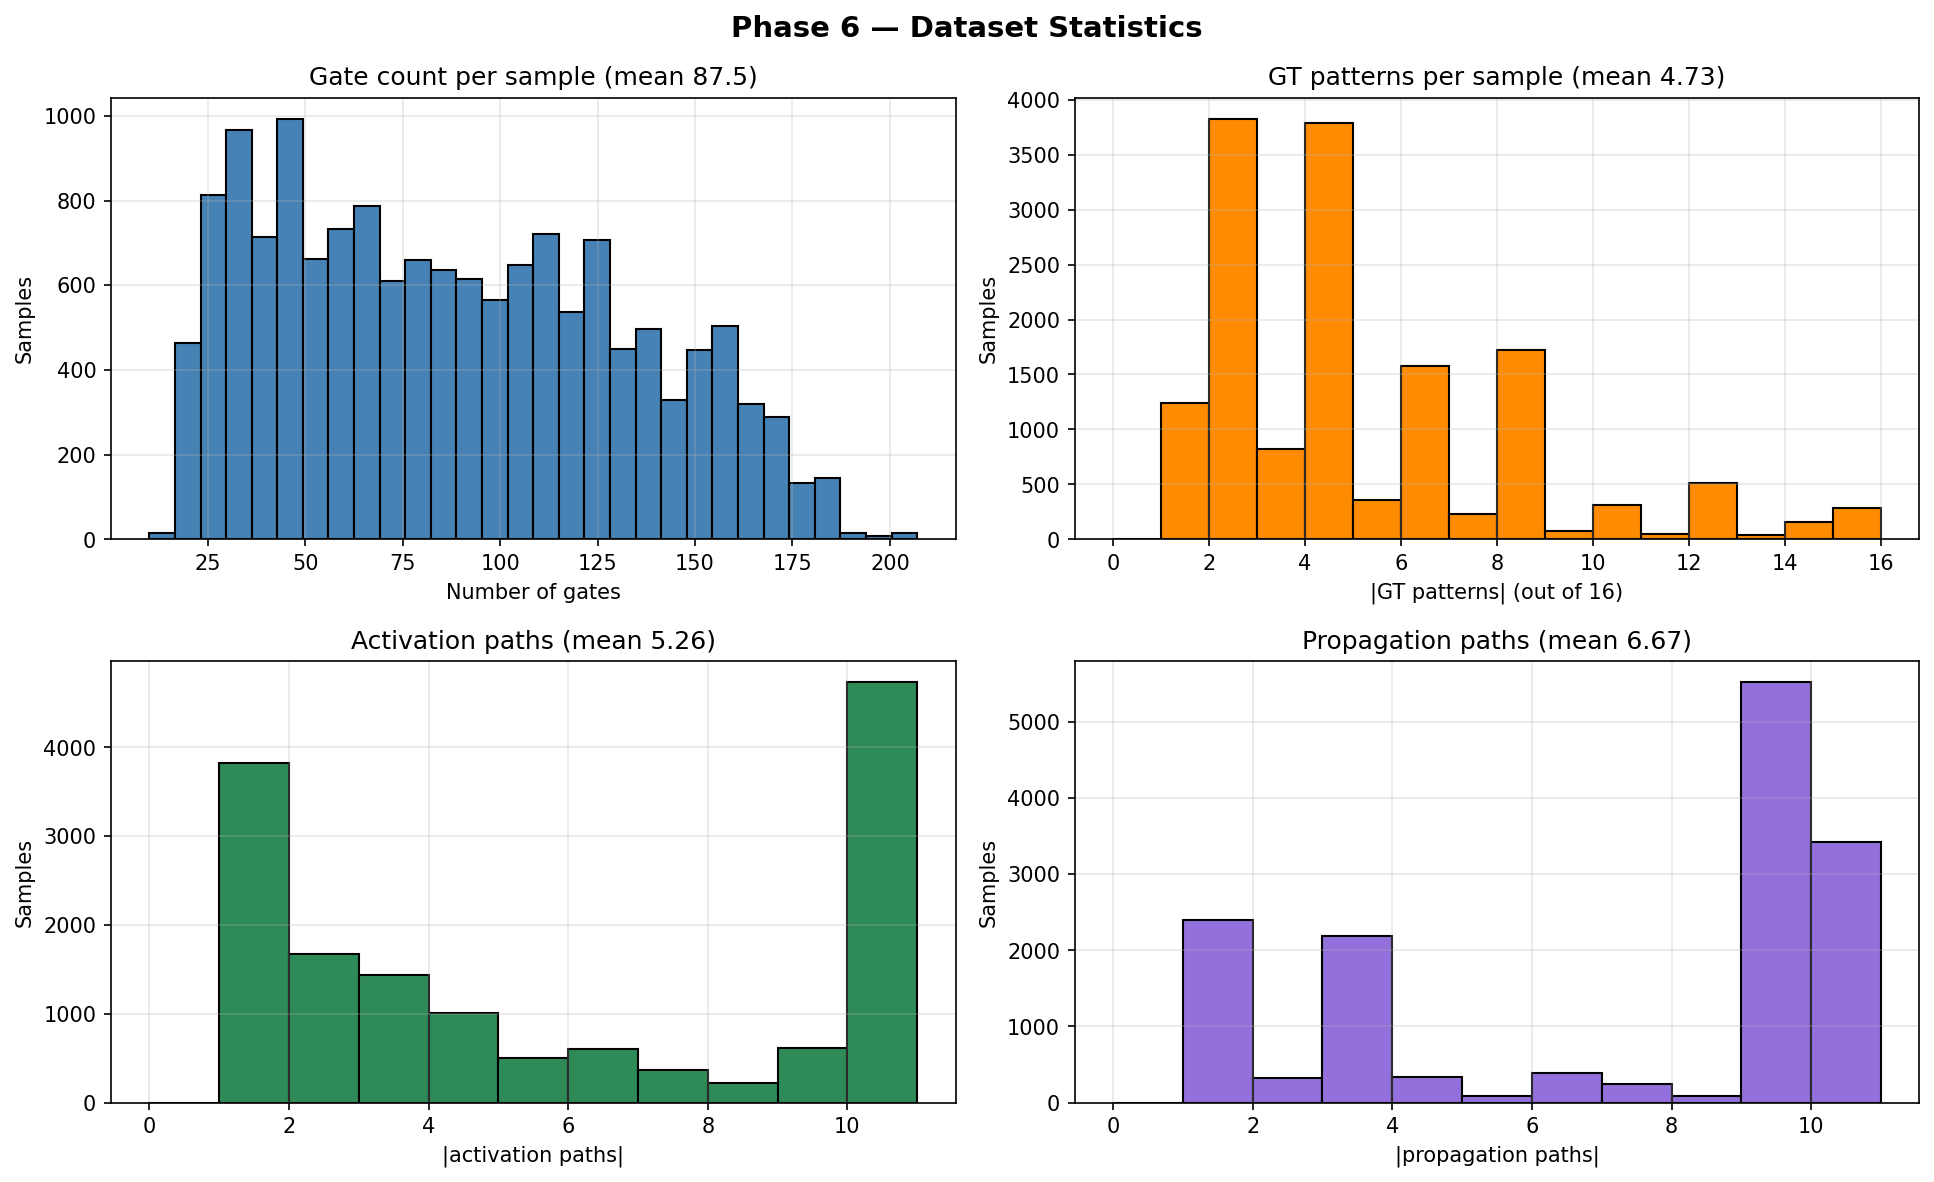

In [10]:
import matplotlib
matplotlib.use("Agg")   # headless backend for Kaggle
import matplotlib.pyplot as plt
from collections import Counter

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

gate_counts = [s["graph"].x.shape[0] for s in dataset]
axes[0,0].hist(gate_counts, bins=30, color="steelblue", edgecolor="black")
axes[0,0].set_title(f"Gate count per sample (mean {sum(gate_counts)/len(gate_counts):.1f})")
axes[0,0].set_xlabel("Number of gates"); axes[0,0].set_ylabel("Samples")
axes[0,0].grid(True, alpha=0.3)

gt_counts = [len(s["gt_patterns"]) for s in dataset]
axes[0,1].hist(gt_counts, bins=range(0,17), color="darkorange", edgecolor="black")
axes[0,1].set_title(f"GT patterns per sample (mean {sum(gt_counts)/len(gt_counts):.2f})")
axes[0,1].set_xlabel("|GT patterns| (out of 16)"); axes[0,1].set_ylabel("Samples")
axes[0,1].grid(True, alpha=0.3)

act_counts = [len(s["act_paths"]) for s in dataset]
axes[1,0].hist(act_counts, bins=range(0,12), color="seagreen", edgecolor="black")
axes[1,0].set_title(f"Activation paths (mean {sum(act_counts)/len(act_counts):.2f})")
axes[1,0].set_xlabel("|activation paths|"); axes[1,0].set_ylabel("Samples")
axes[1,0].grid(True, alpha=0.3)

prop_counts = [len(s["prop_paths"]) for s in dataset]
axes[1,1].hist(prop_counts, bins=range(0,12), color="mediumpurple", edgecolor="black")
axes[1,1].set_title(f"Propagation paths (mean {sum(prop_counts)/len(prop_counts):.2f})")
axes[1,1].set_xlabel("|propagation paths|"); axes[1,1].set_ylabel("Samples")
axes[1,1].grid(True, alpha=0.3)

plt.suptitle("Phase 6 — Dataset Statistics", fontsize=14, fontweight="bold")
plt.tight_layout()
_fig_path = SAVE_PATH+"dataset_stats.png"
plt.savefig(_fig_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"Saved: {_fig_path}")
# Display inline
from IPython.display import Image
Image(_fig_path)


## Phase 7 — Training (hours, checkpointed, resumable)

**Paper settings**: Adam `lr=0.001`, 1000 epochs, BCE loss, best-val checkpoint.

**Kaggle-specific notes:**
- Sessions have a ~9 hour time limit. The loop saves a full checkpoint every `save_every=10` epochs.
- To resume after timeout: re-run **all cells from the top** — the checkpoint is auto-loaded.
- Checkpoints are saved to `/kaggle/working/` which persists for the session.
- Expected time: ~2–4 hours for 1000 epochs on Kaggle T4 GPU.


In [ ]:
import os, torch, torch.nn as nn, torch.optim as optim
import random, time, pickle
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

CHECKPOINT_PATH = SAVE_PATH + "checkpoint_last.pt"
BEST_PATH       = SAVE_PATH + "best_detective_model.pt"


def compute_pattern_accuracy(predicted_bits, gt_patterns):
    if not gt_patterns or not predicted_bits: return 0.0
    hard = [1 if p > 0.5 else 0 for p in predicted_bits]
    n    = len(hard)
    if n == 0: return 0.0
    return max(sum(1 for p,g in zip(hard,gt) if p==g)/n for gt in gt_patterns)


def select_best_gt_pattern(pred_probs, gt_patterns):
    if len(gt_patterns) == 1: return gt_patterns[0]
    hard = [1 if p > 0.5 else 0 for p in pred_probs]
    best = gt_patterns[0]; best_m = -1
    for gt in gt_patterns:
        m = sum(1 for p,g in zip(hard,gt) if p==g)
        if m > best_m: best_m=m; best=gt
    return best


def _build_ext(graph, po_indices):
    return PathExtractor(graph.edge_index, graph.num_nodes, explicit_pos=po_indices)


def train_one_sample(model, sample, optimizer, criterion):
    graph       = sample["graph"]
    fault_idx   = sample["fault_idx"]
    fault_type  = sample["fault_type"]
    pi_indices  = sample["pi_indices"]
    gt_patterns = sample["gt_patterns"]
    act_paths   = sample.get("act_paths")
    prop_paths  = sample.get("prop_paths")

    if not gt_patterns or not pi_indices:
        return None, []

    # ── Phase 1: select best GT pattern ─────────────────────────
    # ONE forward() call covers all PIs — GNN runs once, not N times
    if len(gt_patterns) == 1:
        gt_pattern = gt_patterns[0]
    else:
        model.eval()
        with torch.no_grad():
            preds_sel = model(graph, pi_indices, fault_type,
                              act_paths, prop_paths)   # [N, 1]
        probs_sel  = preds_sel.view(-1).tolist()
        gt_pattern = select_best_gt_pattern(probs_sel, gt_patterns)

    # ── Phase 2: real forward + backprop ────────────────────────
    model.train()
    optimizer.zero_grad()

    preds = model(graph, pi_indices, fault_type,
                  act_paths, prop_paths)   # [N, 1]

    targets = torch.tensor(
        [[float(gt_pattern[i])] for i in range(len(pi_indices))],
        dtype=torch.float,
        device=graph.x.device
    )

    loss = criterion(preds, targets)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    return loss.item(), preds.detach().view(-1).tolist()


def validate_one_sample(model, sample):
    if not sample["gt_patterns"] or not sample["pi_indices"]:
        return [], 0.0

    graph      = sample["graph"]
    fault_type = sample["fault_type"]
    pi_indices = sample["pi_indices"]
    act_paths  = sample.get("act_paths")
    prop_paths = sample.get("prop_paths")

    model.eval()
    with torch.no_grad():
        preds     = model(graph, pi_indices, fault_type,
                          act_paths, prop_paths)   # [N, 1]
        pred_bits = preds.view(-1).tolist()

    return pred_bits, compute_pattern_accuracy(pred_bits, sample["gt_patterns"])

def _val_inner(model, sample):
    """Inner validation — call inside model.eval() + torch.no_grad() scope."""
    if not sample["gt_patterns"] or not sample["pi_indices"]:
        return 0.0
    preds = model(sample["graph"], sample["pi_indices"],
                  sample["fault_type"], sample.get("act_paths"), sample.get("prop_paths"))
    return compute_pattern_accuracy(preds.view(-1).tolist(), sample["gt_patterns"])


def save_checkpoint(path, model, optimizer, epoch, history):
    torch.save({"epoch":epoch,"model_state_dict":model.state_dict(),
                "optimizer_state_dict":optimizer.state_dict(),"history":history}, path)


def run_training(train_dataset, val_dataset, num_epochs=1000,
                 learning_rate=0.001, checkpoint_path=None, best_path=None,
                 save_every=10, log_every=1, resume=True):

    if checkpoint_path is None: checkpoint_path = CHECKPOINT_PATH
    if best_path       is None: best_path       = BEST_PATH

    device    = torch.device("cuda" if _GPU_OK else "cpu")
    model     = DETECTiveModel(in_channels=11, hidden_channels=32, p=10).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.BCELoss()
    history   = {"train_loss":[], "train_accuracy":[], "val_accuracy":[],
                 "best_val":0.0, "best_epoch":0}
    start_epoch = 1

    if resume and os.path.exists(checkpoint_path):
        print(f"Resuming from {checkpoint_path} ...")
        ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        history     = ckpt["history"]
        start_epoch = ckpt["epoch"] + 1
        print(f"  Resumed from epoch {ckpt['epoch']} | "
              f"Best val: {history['best_val']:.4f} (ep {history['best_epoch']})")
    else:
        print("Starting fresh training.")

    print(f"Device      : {device}")
    print(f"Train / Val : {len(train_dataset)} / {len(val_dataset)}")
    print(f"Epochs      : {start_epoch} → {num_epochs}")
    print("="*70)

    if start_epoch > num_epochs:
        print("Already trained. Loading best weights.")
        if os.path.exists(best_path):
            model.load_state_dict(torch.load(best_path, map_location=device,
                                             weights_only=True))
        return model, history

    def to_dev(s):
        return {
        **s,
        "graph":      s["graph"].to(device),
        "fault_type": s["fault_type"].to(device),
        }

    start = time.time()
    epoch = start_epoch - 1   # safe for KeyboardInterrupt before first iteration

    try:
        for epoch in range(start_epoch, num_epochs + 1):
            eloss = eacc = n = 0.0
            random.shuffle(train_dataset)

            pbar = tqdm(train_dataset,
                        desc=f"Ep {epoch:>4}/{num_epochs}",
                        dynamic_ncols=True, leave=False)

            for sample in pbar:
                lv, pb = train_one_sample(model, to_dev(sample), optimizer, criterion)
                if lv is not None:
                    eloss += lv
                    eacc  += compute_pattern_accuracy(pb, sample["gt_patterns"])
                    n     += 1
                    pbar.set_postfix(loss=f"{eloss/n:.4f}", acc=f"{eacc/n:.3f}",
                                     refresh=False)

            al = eloss / max(n, 1)
            aa = eacc  / max(n, 1)
            history["train_loss"].append(al)
            history["train_accuracy"].append(aa)

            # Validation
            model.eval()
            with torch.no_grad():
                vaccs = [_val_inner(model, to_dev(s)) for s in val_dataset]
            av    = sum(vaccs) / max(len(vaccs), 1)
            history["val_accuracy"].append(av)

            # Best model
            best_tag = ""
            if av > history["best_val"]:
                history["best_val"]   = av
                history["best_epoch"] = epoch
                torch.save(model.state_dict(), best_path)
                best_tag = " ★"

            # Checkpoint — THIS NOW ACTUALLY RUNS (dead code bug fixed)
            if epoch % save_every == 0 or epoch == num_epochs:
                save_checkpoint(checkpoint_path, model, optimizer, epoch, history)

            if epoch == start_epoch or epoch % log_every == 0:
                eta = (time.time()-start) / (epoch-start_epoch+1) * (num_epochs-epoch)
                print(f"Ep {epoch:>4}/{num_epochs} | Loss:{al:.4f} | "
                      f"Train:{aa:.4f} | Val:{av:.4f} | "
                      f"Best:{history['best_val']:.4f}(ep{history['best_epoch']}) | "
                      f"ETA:{eta/60:.1f}m{best_tag}")

    except KeyboardInterrupt:
        print(f"\n[!] Interrupted at epoch {epoch} — saving checkpoint...")
        save_checkpoint(checkpoint_path, model, optimizer, epoch, history)
        print(f"Checkpoint: {checkpoint_path}")

    print("="*70)
    print(f"Best val: {history['best_val']:.4f} (epoch {history['best_epoch']})")
    if os.path.exists(best_path):
        model.load_state_dict(torch.load(best_path, map_location=device,
                                         weights_only=True))
    return model, history


def plot_training_history(history):
    if not history["train_loss"]: print("No history yet."); return
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    epochs = range(1, len(history["train_loss"])+1)
    axes[0,0].plot(epochs, history["train_loss"], color="steelblue", lw=1.4)
    axes[0,0].set_title("Training Loss"); axes[0,0].set_xlabel("Epoch")
    axes[0,0].set_ylabel("BCE Loss"); axes[0,0].grid(True, alpha=0.3)
    axes[0,1].plot(epochs, history["train_loss"], color="steelblue", lw=1.4)
    axes[0,1].set_yscale("log"); axes[0,1].set_title("Training Loss (log)")
    axes[0,1].set_xlabel("Epoch"); axes[0,1].grid(True, alpha=0.3, which="both")
    axes[1,0].plot(epochs, history["train_accuracy"], label="Train", color="steelblue", lw=1.4)
    axes[1,0].plot(epochs, history["val_accuracy"],   label="Val",   color="darkorange", lw=1.4)
    axes[1,0].axhline(y=history["best_val"], color="green", ls="--", lw=1,
                      label=f"Best:{history['best_val']:.3f}")
    axes[1,0].axvline(x=history["best_epoch"], color="green", ls=":", lw=1)
    axes[1,0].set_title("Train vs Val Accuracy"); axes[1,0].set_ylim(0,1.05)
    axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)
    w=max(1,min(20,len(list(epochs))//10))
    smoothed=[sum(history["val_accuracy"][max(0,i-w):i+1])/(i+1-max(0,i-w))
              for i in range(len(list(epochs)))]
    axes[1,1].plot(epochs, history["val_accuracy"], color="darkorange", lw=0.8, alpha=0.4, label="Raw")
    axes[1,1].plot(epochs, smoothed, color="darkorange", lw=1.8, label=f"MA-{w}")
    axes[1,1].set_title(f"Val Accuracy (MA-{w})"); axes[1,1].set_ylim(0,1.05)
    axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)
    plt.suptitle("DETECTive — Training Summary", fontsize=14, fontweight="bold")
    plt.tight_layout()
    _fp = SAVE_PATH+"training_curves.png"
    plt.savefig(_fp, dpi=150, bbox_inches="tight"); plt.close()
    print(f"Saved: {_fp}")
    from IPython.display import Image; return Image(_fp)


# ── RUN ──────────────────────────────────────────────────────────
print("\n--- Phase 7: Full Training ---")
trained_model, history = run_training(
    train_dataset=train_dataset, val_dataset=val_dataset,
    num_epochs=EPOCHS, learning_rate=0.001,
    save_every=10, log_every=10, resume=RESUME)

plot_training_history(history)

# ── Post-training accuracy by GT-pattern count ────────────────────
print("="*55)
print(" POST-TRAINING ACCURACY (best weights)")
print("="*55)
_dev2 = torch.device("cuda" if _GPU_OK else "cpu")
_bkts = defaultdict(list)
for _s in val_dataset:
    _s2=dict(_s); _s2["graph"]=_s["graph"].to(_dev2)
    _s2["fault_type"]=_s["fault_type"].to(_dev2)
    _, _acc = validate_one_sample(trained_model, _s2)
    _bkts[len(_s["gt_patterns"])].append(_acc)
print(f"\n{'GT patterns':>12}  {'samples':>8}  {'avg acc':>10}")
print("-"*38)
for k in sorted(_bkts):
    _a = _bkts[k]
    print(f"{k:>12}  {len(_a):>8}  {sum(_a)/len(_a):>10.4f}")
_all = [a for v in _bkts.values() for a in v]
print("-"*38)
print(f"{'OVERALL':>12}  {len(_all):>8}  {sum(_all)/len(_all):>10.4f}")



--- Phase 7: Full Training ---
Starting fresh training.
Device      : cuda
Train / Val : 12000 / 3000
Epochs      : 1 → 1000



[!] Interrupted at epoch 1 — saving checkpoint...
Checkpoint: /kaggle/working/checkpoint_last.pt
Best val: 0.0000 (epoch 0)
No history yet.
 POST-TRAINING ACCURACY (best weights)


## Phase 8 — Inference: Verilog file → predicted test pattern

- `predict_from_verilog(src, fault_node, stuck_val)` — single fault prediction
- `scan_all_faults(src)` — sweep all fault sites


In [ ]:
import os, torch
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


def _load_verilog(src):
    if isinstance(src, str) and os.path.exists(src):
        with open(src) as f: return f.read()
    return src


def _load_best_model(device):
    model = DETECTiveModel(in_channels=11, hidden_channels=32, p=10).to(device)
    if not os.path.exists(BEST_PATH):
        raise FileNotFoundError(f"No weights at {BEST_PATH}. Run Phase 7 first.")
    model.load_state_dict(torch.load(BEST_PATH, map_location=device, weights_only=True))
    model.eval(); return model


def predict_from_verilog(src, fault_node=None, stuck_val=0,
                          model=None, verbose=True, show_plot=True):
    verilog = _load_verilog(src)
    builder = CircuitGraphBuilder(verilog)
    if fault_node is None:
        for n, d in builder.gates.items():
            if d["type"]!="INPUT" and n not in builder.explicit_outputs:
                fault_node=n; break
    if fault_node not in builder.gates:
        raise KeyError(f"Fault node '{fault_node}' not found.")
    graph, node_map = builder.get_pyg_graph(faulty_node=fault_node)
    pi_names   = [n for n,d in builder.gates.items() if d["type"]=="INPUT"]
    pi_indices = [node_map[p] for p in pi_names]
    po_names   = builder.explicit_outputs
    po_indices = [node_map[p] for p in po_names if p in node_map]
    fault_idx  = node_map[fault_node]
    fault_type = torch.tensor([[float(stuck_val)]])
    ext       = PathExtractor(graph.edge_index, graph.num_nodes, explicit_pos=po_indices)
    act_paths = ext.get_activation_paths(fault_idx)
    prop_paths= ext.get_propagation_paths(fault_idx)
    device    = torch.device("cuda" if _GPU_OK else "cpu")
    if model is None: model = _load_best_model(device)
    graph=graph.to(device); fault_type=fault_type.to(device)
    model.eval()
    with torch.no_grad():
        preds = model(graph, pi_indices, fault_type, act_paths, prop_paths)  # [N,1]
    raw_probs = preds.view(-1).tolist()
    predicted_pattern = [1 if p>0.5 else 0 for p in raw_probs]
    gt_patterns=None; accuracy=None
    if len(pi_names)<=6:
        try:
            order=_topological_sort(builder.gates)
            gt_patterns=find_ground_truth_patterns(builder.gates,order,pi_names,po_names,fault_node,stuck_val)
            if gt_patterns: accuracy=compute_pattern_accuracy(raw_probs,gt_patterns)
        except Exception: pass
    result={"predicted_pattern":predicted_pattern,"raw_probabilities":raw_probs,
            "pi_names":pi_names,"fault_node":fault_node,"stuck_value":stuck_val,
            "num_activation_paths":len(act_paths),"num_propagation_paths":len(prop_paths),
            "gt_patterns":gt_patterns,"accuracy":accuracy}
    if verbose:
        print("="*60)
        print(f"Circuit: {len(builder.gates)} nodes, {len(pi_names)} PIs, {len(po_names)} POs")
        print(f"Fault  : {fault_node} stuck-at-{stuck_val}")
        print(f"Act paths: {len(act_paths)}  Prop paths: {len(prop_paths)}")
        print("-"*60)
        for name, bit, raw in zip(pi_names, predicted_pattern, raw_probs):
            bar = "#"*int(raw*30)
            print(f"  {name:<10} = {bit}   (prob={raw:.3f}) |{bar:<30}|")
        if accuracy is not None:
            print(f"GT patterns: {len(gt_patterns)}  Bit-accuracy: {accuracy*100:.1f}%")
            if predicted_pattern in (gt_patterns or []):
                print("Predicted pattern IS in the ground-truth set.")
        print("="*60)
    if show_plot:
        fig, ax = plt.subplots(figsize=(max(5, len(pi_names)*0.8), 4))
        colors  = ["steelblue" if p<0.5 else "darkorange" for p in raw_probs]
        bars    = ax.bar(pi_names, raw_probs, color=colors, edgecolor="black")
        ax.axhline(y=0.5, color="red", ls="--", lw=1, label="0.5 threshold")
        ax.set_ylim(0,1.05); ax.set_ylabel("Sigmoid probability")
        acc_str = f"{accuracy*100:.1f}%" if accuracy is not None else "no GT"
        ax.set_title(f"Fault: {fault_node} SA-{stuck_val}  |  acc: {acc_str}")
        for bar, bit in zip(bars, predicted_pattern):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
                    str(bit), ha="center", fontweight="bold")
        ax.legend(loc="lower right"); plt.tight_layout()
        _fp2 = SAVE_PATH + f"inference_{fault_node}_SA{stuck_val}.png"
        plt.savefig(_fp2, dpi=120, bbox_inches="tight"); plt.close()
        print(f"Plot saved: {_fp2}")
        from IPython.display import Image; display(Image(_fp2))
    return result


def scan_all_faults(src, model=None, verbose=True):
    verilog = _load_verilog(src)
    builder = CircuitGraphBuilder(verilog)
    device  = torch.device("cuda" if _GPU_OK else "cpu")
    if model is None: model = _load_best_model(device)
    sites   = [n for n,d in builder.gates.items()
               if d["type"]!="INPUT" and n not in builder.explicit_outputs]
    results = []
    for fn in sites:
        for sv in [0,1]:
            r=predict_from_verilog(verilog,fn,sv,model=model,verbose=False,show_plot=False)
            results.append(r)
    if verbose:
        print(f"Scanned {len(results)} faults ({len(sites)} sites x 2 SA values)")
        print(f"{'fault':<10} {'SA':<4} {'pattern':<25} {'|act|':<7} {'|prop|':<7} {'acc':>6}")
        print("-"*65)
        for r in results:
            acc_s = f"{r['accuracy']*100:.1f}%" if r["accuracy"] is not None else "n/a"
            print(f"{r['fault_node']:<10} {r['stuck_value']:<4} "
                  f"{str(r['predicted_pattern']):<25} "
                  f"{r['num_activation_paths']:<7} {r['num_propagation_paths']:<7} {acc_s:>6}")
    return results


print("Phase 8 inference API ready.")
print("  predict_from_verilog(src, fault_node, stuck_val)")
print("  scan_all_faults(src)")


### Example inference

Edit `VERILOG_INPUT`, `FAULT_NODE`, and `STUCK_VAL`, then run.


In [ ]:
VERILOG_INPUT = """
module example (a, b, c, y);
    input a, b, c;
    output y;
    wire d;
    and G1(d, a, b);
    or  G2(y, d, c);
endmodule
"""

FAULT_NODE = "d"   # None to auto-pick
STUCK_VAL  = 0     # 0 or 1

result = predict_from_verilog(VERILOG_INPUT, FAULT_NODE, STUCK_VAL)

print("\n--- Full fault scan on the same circuit ---")
_ = scan_all_faults(VERILOG_INPUT)
